## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, precision_recall_curve
import shap

In [2]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

## Load Dataset

In [3]:
train_transaction = pd.read_csv("../data/raw/train_transaction.csv")
train_identity = pd.read_csv("../data/raw/train_identity.csv")

test_transaction = pd.read_csv("../data/raw/test_transaction.csv")
test_identity = pd.read_csv("../data/raw/test_identity.csv")

## Check Shapes

In [4]:
print(train_transaction.shape)
print(train_identity.shape)

print(test_transaction.shape)
print(test_identity.shape)

(590540, 394)
(144233, 41)
(506691, 393)
(141907, 41)


## Merge Datasets

In [5]:
train_df = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

test_df = test_transaction.merge(
    test_identity,
    on="TransactionID",
    how="left"
)

In [6]:
print(train_df.shape)
print(test_df.shape)

(590540, 434)
(506691, 433)


In [7]:
test_df.columns = [col.replace("-", "_")for col in test_df.columns]

In [8]:
test_df.to_csv( "../data/raw/test_df.csv", index=False)

In [9]:
sample_df = test_df.sample(5000, random_state=42)

In [10]:
sample_df.to_csv("../data/raw/sample_test_df.csv", index=False)

## Check Duplicate IDs

In [11]:
train_df["TransactionID"].duplicated().sum()

np.int64(0)

## Check Missing Target values

In [12]:
train_df["isFraud"].isnull().sum()

np.int64(0)

## Inspect Data

In [13]:
pd.set_option('display.max_columns', None)
train_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [14]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [15]:
train_df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,37627.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,421571.000000,421571.000000,421571.000000,421571.00000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,590226.000000,590226.00000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.0000

## Inspect Target Variable

In [16]:
train_df["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [17]:
train_df["isFraud"].value_counts(normalize=True)*100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

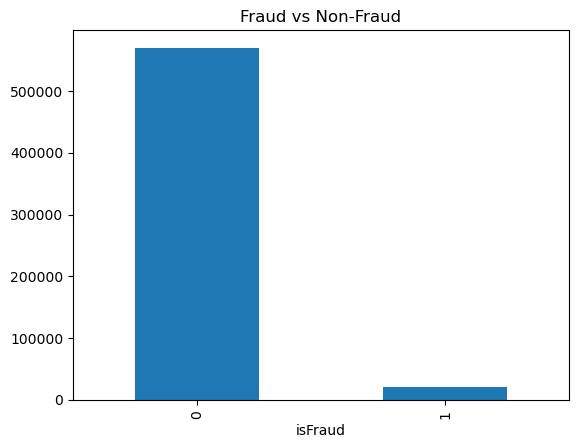

In [18]:
train_df["isFraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud")
plt.show()

## Analyze Missing Values

In [19]:
missing_percent = (
    train_df.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)
missing_percent.head(30)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
D8       87.312290
id_10    87.312290
D9       87.312290
id_30    86.865411
id_32    86.861855
id_34    86.824771
id_14    86.445626
V138     86.123717
V139     86.123717
V148     86.123717
dtype: float64

## Analyze Column Types

In [20]:
train_df.dtypes.value_counts()

float64    399
str         31
int64        4
Name: count, dtype: int64

## Check Memory Usage

In [21]:
train_df.memory_usage().sum() / 1024**2

np.float64(1984.1981496810913)

## Create Memory Optimization Function

In [22]:
def reduce_mem_usage(df):

    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory Usage Before: {start_mem:.2f} MB")

    for col in df.columns:

        col_type = df[col].dtype

        if pd.api.types.is_numeric_dtype(df[col]):

            c_min = df[col].min()
            c_max = df[col].max()

            if pd.api.types.is_integer_dtype(df[col]):

                if c_min > -128 and c_max < 127:
                    df[col] = df[col].astype('int8')

                elif c_min > -32768 and c_max < 32767:
                    df[col] = df[col].astype('int16')

                elif c_min > -2147483648 and c_max < 2147483647:
                    df[col] = df[col].astype('int32')

            else:
                df[col] = df[col].astype('float32')

        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory Usage After: {end_mem:.2f} MB")

    return df

In [23]:
train_df = reduce_mem_usage(train_df)
test_df = reduce_mem_usage(test_df)

Memory Usage Before: 1984.20 MB
Memory Usage After: 924.24 MB
Memory Usage Before: 1700.29 MB
Memory Usage After: 792.54 MB


## Save Optimized Data

In [24]:
train_df.to_pickle("../data/processed/train_optimized.pkl")
test_df.to_pickle("../data/processed/test_optimized.pkl")

## Define Features & Target

In [25]:
X = train_df.drop(["isFraud", "TransactionID"], axis=1)
y = train_df["isFraud"]
X_test = test_df.drop(["TransactionID"], axis=1)

## Train/Validation Split

In [26]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

In [27]:
missing_cols = set(X_train.columns) - set(test_df.columns)
extra_cols = set(test_df.columns) - set(X_train.columns)
print("Missing:", missing_cols)
print("Extra:", extra_cols)

Missing: set()
Extra: {'TransactionID'}


## Verify Split Distribution

### Train Distribution

In [28]:
y_train.value_counts(normalize=True)*100

isFraud
0    96.501084
1     3.498916
Name: proportion, dtype: float64

### Validation Distribution

In [29]:
y_valid.value_counts(normalize=True)*100

isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64

In [30]:
for col in X_train.columns:
    if "string" in str(X_train[col].dtype):
        X_train[col] = X_train[col].astype("object")
        X_valid[col] = X_valid[col].astype("object")
        X_test[col] = X_test[col].astype("object")

## Check Column Types

In [31]:
cat_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)

In [32]:
num_cols = list(X_train.select_dtypes(include=['int', 'float']).columns)

In [33]:
print(len(cat_cols))
print(len(num_cols))

31
400


## Create Numerical Pipeline

In [34]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

## Create Categorical Pipeline

In [35]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Combine Pipelines

In [36]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

## Create Baseline Model Pipeline

In [37]:
model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

## Train Baseline Model

In [38]:
model_pipeline.fit(X_train, y_train)

C:\Users\ameeen\anaconda3\envs\project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Make Predictions

In [39]:
y_pred = model_pipeline.predict(X_valid)

## Probability Predictions

In [40]:
y_prob = model_pipeline.predict_proba(X_valid)[:, 1]

## Classification Report

print(classification_report(y_valid, y_pred))

## ROC-AUC

In [41]:
roc_auc = roc_auc_score(y_valid, y_prob)
print(roc_auc)

0.7030616790997427


## PR-AUC

In [42]:
pr_auc = average_precision_score(y_valid, y_prob)
print(pr_auc)

0.12104963217126921


## Save Pipeline

In [43]:
joblib.dump(model_pipeline, "../models/logistic_pipeline.pkl")

['../models/logistic_pipeline.pkl']

## Create New Weighted Model

In [44]:
weighted_model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
])

## Train New Model

In [45]:
weighted_model_pipeline.fit(X_train, y_train)

C:\Users\ameeen\anaconda3\envs\project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict

In [46]:
weighted_y_pred = weighted_model_pipeline.predict(X_valid)

## Predict Probabilities

In [47]:
weighted_y_prob = weighted_model_pipeline.predict_proba(X_valid)[:, 1]

## Evaluate

In [48]:
print(classification_report(y_valid, weighted_y_pred))

              precision    recall  f1-score   support

           0       0.98      0.68      0.81    113975
           1       0.07      0.65      0.13      4133

    accuracy                           0.68    118108
   macro avg       0.53      0.67      0.47    118108
weighted avg       0.95      0.68      0.78    118108



## ROC-AUC

In [49]:
roc_auc_score(y_valid, weighted_y_prob)

0.741513141648437

## PR-AUC

In [50]:
average_precision_score(y_valid, weighted_y_prob)

0.1259127152123831

## Save Model

In [51]:
joblib.dump(weighted_model_pipeline, "../models/weighted_logistic_pipeline.pkl")

['../models/weighted_logistic_pipeline.pkl']

## Create Random Forest Pipeline

In [52]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=SEED))
])

## Train Model

In [53]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict

In [54]:
rf_y_pred = rf_pipeline.predict(X_valid)

## Probabilities

In [55]:
rf_y_prob = rf_pipeline.predict_proba(X_valid)[:, 1]

## Classification Report

In [56]:
print(classification_report(y_valid, rf_y_pred))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92    113975
           1       0.16      0.73      0.26      4133

    accuracy                           0.86    118108
   macro avg       0.57      0.79      0.59    118108
weighted avg       0.96      0.86      0.90    118108



## ROC-AUC

In [57]:
roc_auc_score(y_valid, rf_y_prob)

0.8736854755938843

## PR-AUC

In [58]:
average_precision_score(y_valid, rf_y_prob)

0.48877460816060764

## Save Random Forest Model

In [59]:
joblib.dump(rf_pipeline, "../models/random_forest_pipeline.pkl")

['../models/random_forest_pipeline.pkl']

## Model Comparison

In [60]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Weighted Logistic", "Random Forest"],
    "ROC_AUC": [0.703, 0.742, 0.874],
    "PR_AUC": [0.121, 0.126, 0.489],
    "Fraud_Recall": [0.01, 0.65, 0.73],
    "Fraud_Precision": [0.43, 0.07, 0.16]
})
results.sort_values(by="PR_AUC", ascending=False)

,Model,ROC_AUC,PR_AUC,Fraud_Recall,Fraud_Precision
2,Random Forest,0.874,0.489,0.73,0.16
1,Weighted Logistic,0.742,0.126,0.65,0.07
0,Logistic Regression,0.703,0.121,0.01,0.43


## FEATURE IMPORTANCE

In [61]:
rf_model = rf_pipeline.named_steps["model"]
preprocessor = rf_pipeline.named_steps["preprocessing"]

In [62]:
num_features = num_cols

In [63]:
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]

In [64]:
encoded_cat_features = cat_encoder.get_feature_names_out(cat_cols)

In [65]:
all_features = list(num_features) + list(encoded_cat_features)

In [66]:
feature_importance = pd.DataFrame({"Feature": all_features, "Importance": rf_model.feature_importances_})

In [67]:
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

In [68]:
feature_importance.head(20)

,Feature,Importance
106,V69,0.020868
67,V30,0.017704
21,C13,0.017275
3,card3,0.016138
127,V90,0.015934
295,V258,0.015542
18,C10,0.015511
66,V29,0.015010
16,C8,0.013918
311,V274,0.013344


In [69]:
top_features = feature_importance.head(20)

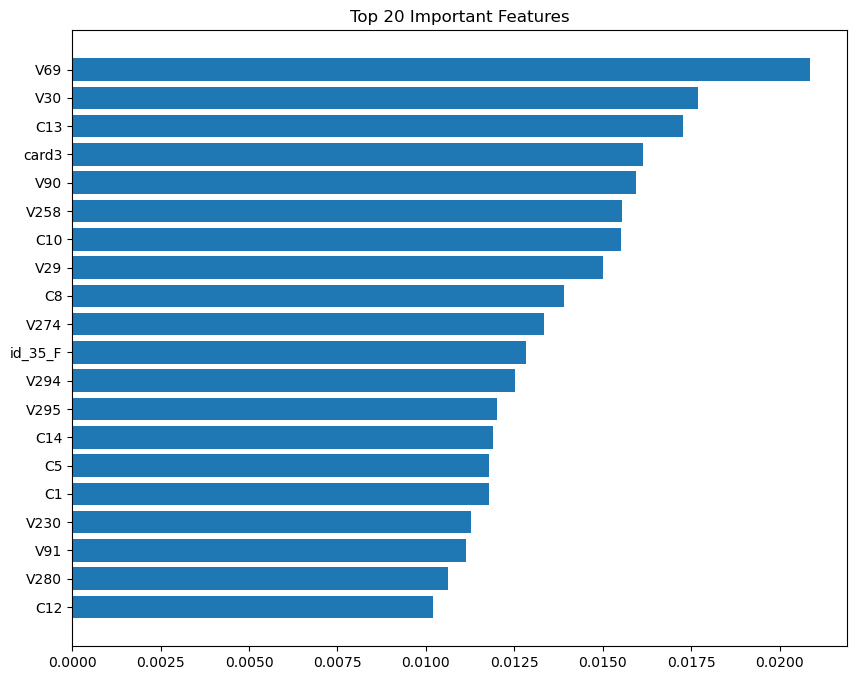

In [70]:
plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

## Create XGBoost Pipeline

In [71]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=SEED,
            n_jobs=-1
        ))
])

## Train XGBoost

In [72]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict

In [73]:
xgb_y_pred = xgb_pipeline.predict(X_valid)

## Predict Probabilities

In [74]:
xgb_y_prob = xgb_pipeline.predict_proba(X_valid)[:, 1]

## Classification Report

In [75]:
print(classification_report(y_valid, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.91      0.45      0.61      4133

    accuracy                           0.98    118108
   macro avg       0.94      0.73      0.80    118108
weighted avg       0.98      0.98      0.98    118108



## ROC-AUC

In [76]:
xgb_roc_auc = roc_auc_score(y_valid, xgb_y_prob)
print(xgb_roc_auc)

0.9321068240596566


## PR-AUC

In [77]:
xgb_pr_auc = average_precision_score(y_valid, xgb_y_prob)
print(xgb_pr_auc)

0.6930920790934487


## Model Comparison

In [78]:
new_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "ROC_AUC": [xgb_roc_auc],
    "PR_AUC": [xgb_pr_auc],
    "Fraud_Recall": [recall_score(y_valid, xgb_y_pred)],
    "Fraud_Precision": [precision_score(y_valid, xgb_y_pred)]
})

In [79]:
results = pd.concat([results, new_row], ignore_index=True)

In [80]:
results.sort_values(by="PR_AUC", ascending=False)

,Model,ROC_AUC,PR_AUC,Fraud_Recall,Fraud_Precision
3,XGBoost,0.932107,0.693092,0.453666,0.909311
2,Random Forest,0.874000,0.489000,0.730000,0.160000
1,Weighted Logistic,0.742000,0.126000,0.650000,0.070000
0,Logistic Regression,0.703000,0.121000,0.010000,0.430000


## Precision-Recall Curve

In [81]:
precisions, recalls, thresholds = precision_recall_curve(y_valid, xgb_y_prob)

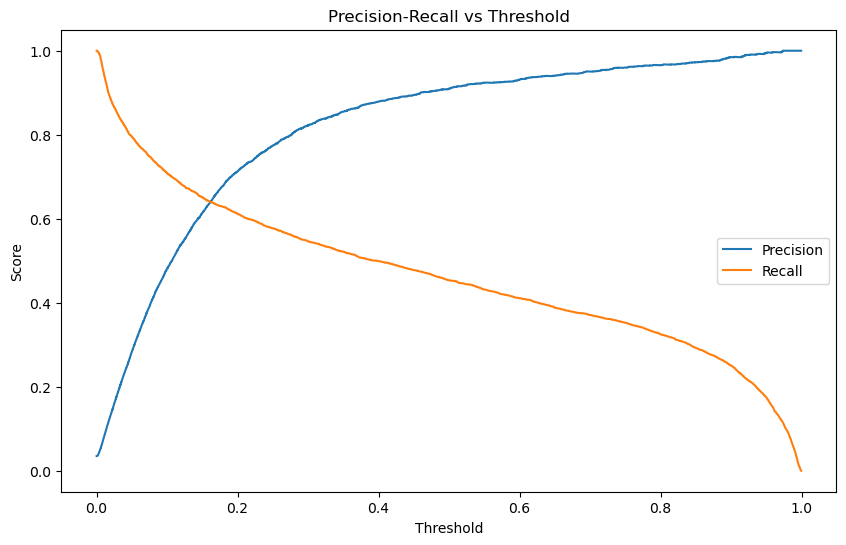

In [82]:
plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precisions[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recalls[:-1],
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

## Lower the Threshold

In [83]:
custom_pred = (xgb_y_prob >= 0.3).astype(int)

In [84]:
print(classification_report(y_valid, custom_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.82      0.55      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.90      0.77      0.82    118108
weighted avg       0.98      0.98      0.98    118108



In [85]:
precision_score(y_valid, custom_pred)

0.8222869628550619

In [86]:
recall_score(y_valid, custom_pred)

0.5463343818049843

## SHAP

In [87]:
xgb_model = xgb_pipeline.named_steps["model"]

In [88]:
X_valid_transformed = preprocessor.transform(X_valid)

In [89]:
explainer = shap.TreeExplainer(xgb_model)

In [90]:
sample_data = X_valid_transformed[:1000]

In [91]:
shap_values = explainer.shap_values(sample_data)

C:\Users\ameeen\AppData\Local\Temp\ipykernel_21204\4069917483.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample_data)


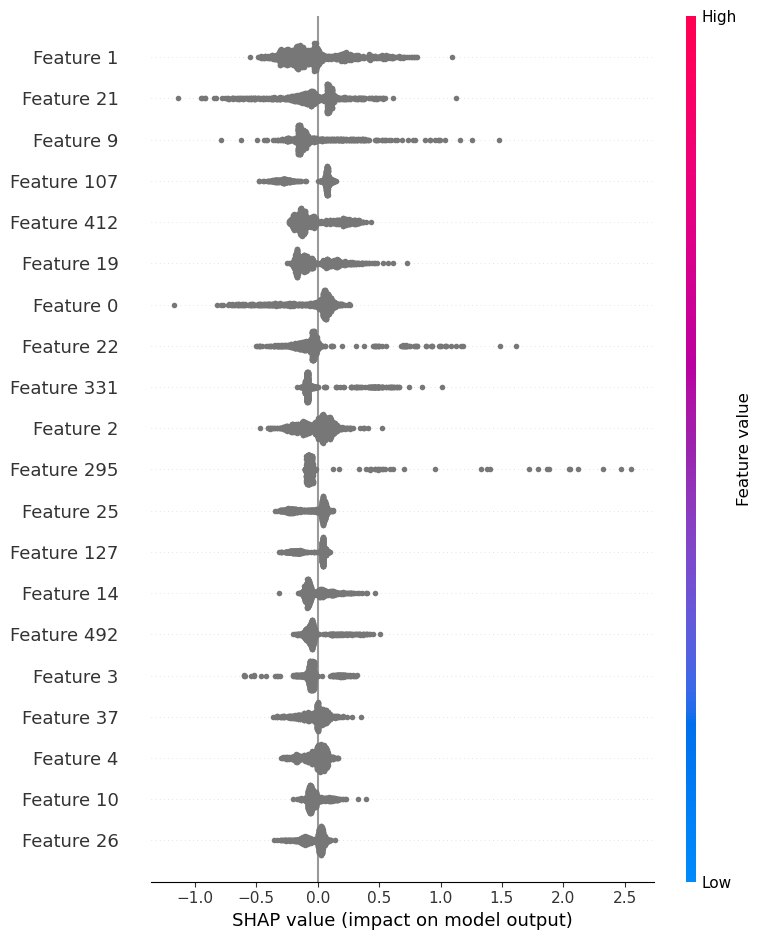

In [92]:
shap.summary_plot(shap_values, sample_data)

## Waterfall Plot

In [93]:
sample_y = y_valid.iloc[:1000]

In [94]:
fraud_index = np.where(sample_y.values == 1)[0][0]

In [95]:
sample_dense = sample_data.toarray()

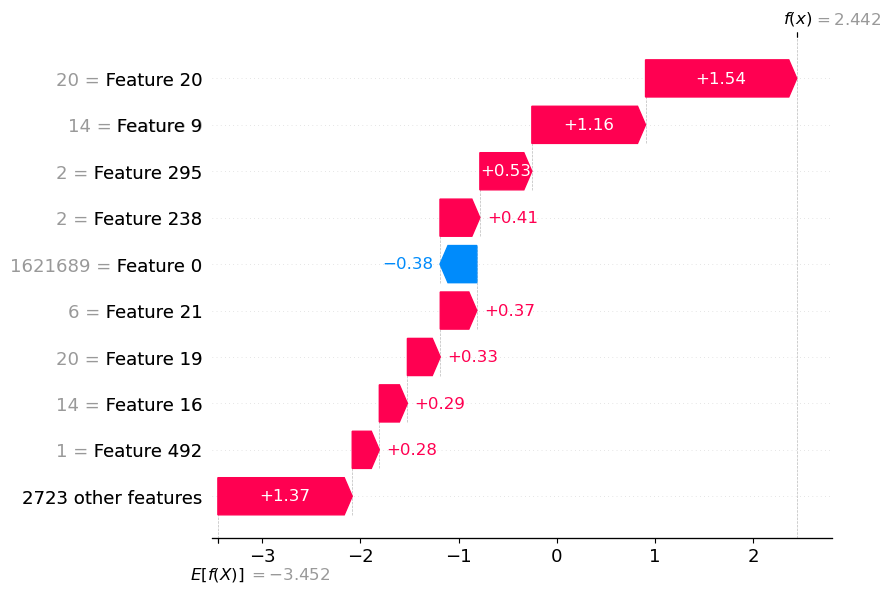

In [96]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[fraud_index],
        base_values=explainer.expected_value,
        data=sample_dense[fraud_index]
    )
)

## FRAUD RISK SCORING

In [97]:
fraud_results = X_valid.copy()

In [98]:
fraud_results["Actual_Fraud"] = y_valid.values

In [99]:
fraud_results["Fraud_Probability"] = xgb_y_prob

In [100]:
fraud_results["Predicted_Fraud"] = custom_pred

In [101]:
def assign_risk_level(prob):

    if prob >= 0.9:
        return "Critical"

    elif prob >= 0.7:
        return "High"

    elif prob >= 0.4:
        return "Medium"

    else:
        return "Low"

In [102]:
fraud_results["Risk_Level"] = (fraud_results["Fraud_Probability"].apply(assign_risk_level))

In [103]:
fraud_results = fraud_results.sort_values(by="Fraud_Probability", ascending=False)

In [104]:
fraud_results.head(20)

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,Actual_Fraud,Fraud_Probability,Predicted_Fraud,Risk_Level
176286,3812152,250.000000,R,4141,404.0,150.0,mastercard,102.0,credit,264.0,87.0,NaN,NaN,gmail.com,gmail.com,6.0,7.0,0.0,2.0,0.0,9.0,0.0,6.0,0.0,5.0,4.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,3.0,4.0,11.0,1.0,1.0,0.0,1.0,6.0,0.0,5.0,1.0,4.0,6.0,2.0,5.0,1.0,4.0,1.0,4.0,1.0,4.0,0.0,250.0,250.0,250.0,250.0,0.0,1000.0,250.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,191246.0,NaN,NaN,17.0,-25.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,15.0,321.0,500.0,NaN,NaN,NaN,NaN,

In [105]:
fraud_results["Risk_Level"].value_counts()

Risk_Level
Low         115761
Critical      1053
Medium         734
High           560
Name: count, dtype: int64

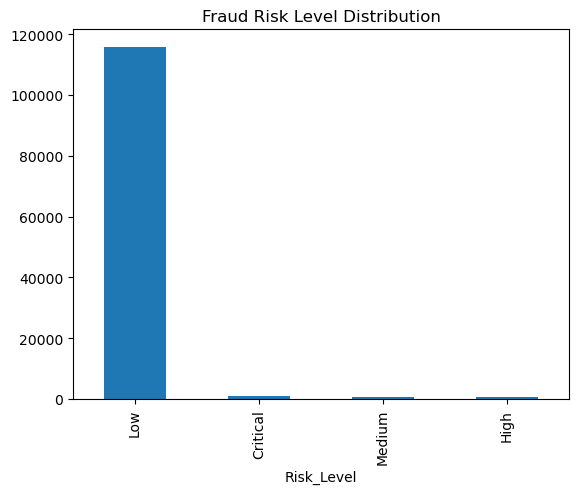

In [106]:
fraud_results["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Fraud Risk Level Distribution")
plt.show()

In [107]:
pd.crosstab(fraud_results["Risk_Level"], fraud_results["Actual_Fraud"])

Actual_Fraud,0,1
Risk_Level,,
Critical,16,1037
High,64,496
Low,113691,2070
Medium,204,530


## Save Model

In [108]:
joblib.dump(xgb_pipeline, "../models/xgboost_pipeline.pkl")

['../models/xgboost_pipeline.pkl']

In [109]:
sample_test = X_valid.head(100)

In [110]:
sample_test.to_csv("../outputs/sample_transactions.csv", index=False)